---
#**Necessary imports**
---
Need to be run two times

In [1]:
!pip install obspy
import obspy
from obspy.clients.fdsn import Client
import pandas as pd
import numpy as np
from obspy.core import UTCDateTime
from obspy.clients.fdsn import Client
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
import matplotlib.pyplot as plt
import glob
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
#**Start of the simulation**
---
The first part of the program creates fake earthquakes datas to train the model into predict if a tsunami will be a consequence of an earthquake

In [2]:
#---Simulation ---
np.random.seed(42)

#Tsunami: Yes = 1 ; No = 0
num_events = 300

#Feature
magnitudes = np.random.uniform(7.0, 9.5, num_events)
depths = np.random.uniform(10, 80, num_events)
foreshocks = np.random.randint(0, 15, num_events)
bvals = np.random.uniform(0.6, 1.5, num_events)

#Target
tsunami_prob = ((magnitudes > 8.0) * 0.4 + (depths < 30) * 0.3)
tsunami_generated = (np.random.rand(num_events) < tsunami_prob).astype(int)

# Infine costruisci il dizionario
data = {
    'Magnitude': magnitudes,
    'Depth_km': depths,
    'Foreshock_Count_48h': foreshocks,
    'B_Value_Pre': bvals,
    'Tsunami_Generated': tsunami_generated
}

df_events = pd.DataFrame(data)

#LSTM input
#60 seconds, 100 hz, 6000 points
SEQUENCE_LENGTH = 6000
X_seq_data = np.random.rand(num_events, SEQUENCE_LENGTH, 1)

In [3]:
#Target tag
Y = df_events['Tsunami_Generated'].values

#Statistic feature
STATIC_FEATURES = ['Magnitude', 'Depth_km', 'Foreshock_Count_48h', 'B_Value_Pre']
X_static = df_events[STATIC_FEATURES].values

#Normalization of statistic feature
scaler = StandardScaler()
X_static_scaled = scaler.fit_transform(X_static)

#Datas division
#70% training, 15% validitation and 15% test
X_train_static, X_temp_static, Y_train, Y_temp = train_test_split(
    X_static_scaled, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val_static, X_test_static, Y_val, Y_test = train_test_split(
    X_temp_static, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)


X_train_seq, X_temp_seq, _, _ = train_test_split(
    X_seq_data, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val_seq, X_test_seq, _, _ = train_test_split(
    X_temp_seq, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)

print(f"Dataset di Training: {len(Y_train)} eventi")
print(f"Dataset di Test: {len(Y_test)} eventi")

Dataset di Training: 210 eventi
Dataset di Test: 45 eventi


In [4]:
#Input dimension
seq_input_shape = (SEQUENCE_LENGTH, 1) # (6000, 1)
static_input_shape = (len(STATIC_FEATURES),) # (4,)

#First step: LSTM
seq_input = Input(shape=seq_input_shape, name='Seismic_Sequence_Input')
x = LSTM(64, activation='tanh')(seq_input)
x = Dropout(0.3)(x)
lstm_output = Dense(32, activation='relu')(x)

#Second step: feature Engineering/Foreshock
static_input = Input(shape=static_input_shape, name='Static_Features_Input')
y = Dense(16, activation='relu')(static_input)
y = Dropout(0.3)(y)
static_output = Dense(32, activation='relu')(y)

#Steps fusion
merged = Concatenate()([lstm_output, static_output])
z = Dense(32, activation='relu')(merged)
z = Dropout(0.3)(z)

#Final output
output = Dense(1, activation='sigmoid', name='Tsunami_Output')(z)

#Definition of the final model
model = Model(inputs=[seq_input, static_input], outputs=output)

#Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Seismic_Sequence_I… │ (None, 6000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Static_Features_In… │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     16,896 │ Seismic_Sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         80 │ Static_Features_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Tsunami_Output      │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,713 (84.82 KB)

 Trainable params: 21,713 (84.82 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#---Training ---
print("\n--- Start of the model training ---")

history = model.fit(
    # Input: [sequential, statistic]
    [X_train_seq, X_train_static],
    Y_train,
    epochs=100,
    batch_size=32,
    validation_data=([X_val_seq, X_val_static], Y_val),
    verbose=1
)

#---Valutation---
print("\n--- Valutation of the test set ---")
loss, accuracy, recall, precision = model.evaluate(
    [X_test_seq, X_test_static],
    Y_test,
    verbose=0
)

print(f"Accuracy of the test Set: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

#---Prediction for the confusion matrix ---
Y_pred_proba = model.predict([X_test_seq, X_test_static])
Y_pred = (Y_pred_proba > 0.289).astype(int)


--- Start of the model training ---
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7855 - loss: 0.4324 - precision: 0.6909 - recall: 0.6508 - val_accuracy: 0.7111 - val_loss: 0.4283 - val_precision: 0.5294 - val_recall: 0.6429
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7922 - loss: 0.4451 - precision: 0.6967 - recall: 0.6079 - val_accuracy: 0.7111 - val_loss: 0.4301 - val_precision: 0.5294 - val_recall: 0.6429
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8308 - loss: 0.4062 - precision: 0.7778 - recall: 0.6323 - val_accuracy: 0.7111 - val_loss: 0.4323 - val_precision: 0.5294 - val_recall: 0.6429
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7588 - loss: 0.4193 - precision: 0.6728 - recall: 0.4002 - val_accuracy: 0.7333 - val_loss: 0.4343 - val_precision: 0.5625 - val_recall: 0.6429
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8307 - loss: 0.3963 - precision: 0.7788 - recall: 0.5981 - val_accuracy:

---
#**Graphics**
---
Loss and Accuracy curves, Confusion Matrix

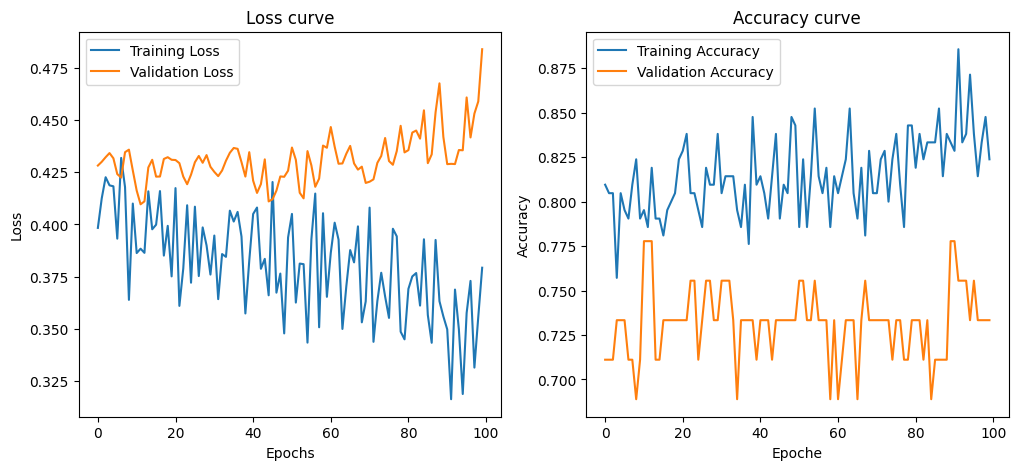

<Figure size 600x600 with 0 Axes>

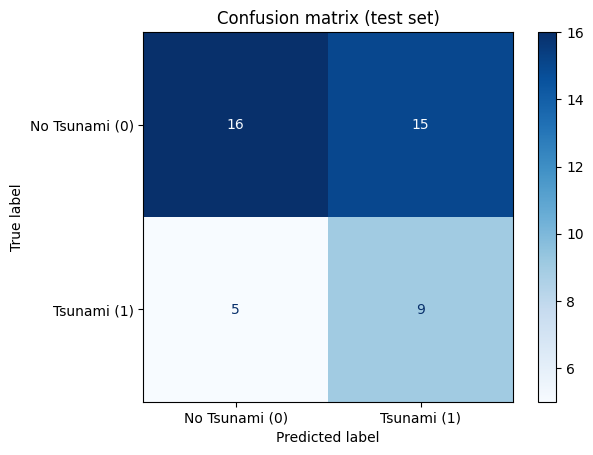

In [10]:
#Graphic 1: Loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#Graphic 2: Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy curve')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Graphic 3: Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tsunami (0)', 'Tsunami (1)'])
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion matrix (test set)')
plt.show()

In [ ]:
'''
TP -> True Positive (prevision about the tsunami was correct)
FN -> False Negative (prevision about the abscence of tsunami was incorrect) [worst case]
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
'''

---
#**Real data CSV creation**
---

If the CSV is saved in the Drive, there is no need to run this part (03/01/2026)

JAM site DAT files:
https://www.data.jma.go.jp/eqev/data/bulletin/data/shindo/format_e.txt

In [ ]:
# ---Paths---
cartella_input = "/content/drive/MyDrive/DAT/"
output_path = "/content/drive/MyDrive/jma_all_years.csv"

# ---Columns---
col_specs = [
    (0, 1), (1, 5), (5, 7), (7, 9), (9, 11), (11, 13), (13, 17),
    (21, 24), (24, 28), (32, 36), (36, 40), (44, 49), (52, 54), (63, 64)
]
col_names = ["RecType", "Year", "Month", "Day", "Hour", "Minute", "Second",
             "LatDeg", "LatMin", "LonDeg", "LonMin", "Depth_raw", "Mag_raw", "Tsunami_raw"]

all_dfs = []

# 2.File search
files = glob.glob(os.path.join(cartella_input, "*.dat")) + glob.glob(os.path.join(cartella_input, "*.DAT"))
files = sorted(files)

print(f"Total number of files in the folder: {len(files)}")

for file in files:
    nome_f = os.path.basename(file)
    try:
        #Loading
        df = pd.read_fwf(file, colspecs=col_specs, names=col_names, header=None, dtype=str, encoding='shift_jis')

        righe_totali = len(df)

        #Filter
        df = df[df['RecType'].isin(['A', 'B', 'D'])].copy()
        righe_filtrate = len(df)

        if righe_filtrate == 0:
            print(f"⚠️ Warning: {nome_f} , missing A, B or D")
            continue

        #Conversion
        for col in ["Year", "Month", "Day", "Hour", "Minute", "Second", "LatDeg", "LatMin", "LonDeg", "LonMin", "Depth_raw", "Mag_raw"]:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df['Second'] = df['Second'] / 100
        df['Latitude'] = df['LatDeg'] + (df['LatMin'] / 100 / 60)
        df['Longitude'] = df['LonDeg'] + (df['LonMin'] / 100 / 60)
        df['Depth_km'] = df['Depth_raw'] / 100
        df['Magnitude'] = df['Mag_raw'] / 10
        df['Tsunami'] = df['Tsunami_raw'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() in ["", "0"] else 1)

        df_final_step = df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth_km', 'Magnitude', 'Tsunami']].copy()
        df_final_step = df_final_step.dropna(subset=['Year'])

        all_dfs.append(df_final_step)
        print(f"✅ {nome_f}: found {righe_filtrate} sismic events.")

    except Exception as e:
        print(f"❌ Critic error in file {nome_f}: {e}")

# 3.Final try
if all_dfs:
    df_final = pd.concat(all_dfs, ignore_index=True)

    #Years check
    anni_presenti = sorted(df_final['Year'].unique().astype(int))
    print(f"\n---Final record---")
    print(f"Total loaded events: {len(df_final)}")
    print(f"Years found into CSV: from {anni_presenti[0]} to {anni_presenti[-1]}")
    print(f"Total number of singular years: {len(anni_presenti)}")

    df_final.to_csv(output_path, index=False)
    print(f"File saved in: {output_path}")
else:
    print("No data loaded")

Total number of files in the folder: 31
✅ i1992.dat: found 1980 sismic events.
✅ i1993.dat: found 1597 sismic events.
✅ i1994.dat: found 816 sismic events.
✅ i1995.dat: found 2006 sismic events.
✅ i1996.dat: found 1164 sismic events.
✅ i1997.dat: found 1794 sismic events.
✅ i1998.dat: found 1549 sismic events.
✅ i1999.dat: found 1037 sismic events.
✅ i2000.dat: found 17761 sismic events.
✅ i2001.dat: found 1530 sismic events.
✅ i2002.dat: found 1263 sismic events.
✅ i2003.dat: found 2296 sismic events.
✅ i2004.dat: found 2271 sismic events.
✅ i2005.dat: found 1725 sismic events.
✅ i2006.dat: found 1346 sismic events.
✅ i2007.dat: found 2136 sismic events.
✅ i2008.dat: found 1940 sismic events.
✅ i2009.dat: found 1649 sismic events.
✅ i2010.dat: found 1325 sismic events.
✅ i2011.dat: found 10902 sismic events.
✅ i2012.dat: found 3164 sismic events.
✅ i2013.dat: found 2429 sismic events.
✅ i2014.dat: found 2076 sismic events.
✅ i2015.dat: found 1849 sismic events.
✅ i2016.dat: found 7104

---
#**Real data usage**
---

In [ ]:
#CSV load
df = pd.read_csv("/content/drive/MyDrive/jma_all_years.csv")

#Columns selection
FEATURES = ["Magnitude", "Depth_km"]
TARGET = "Tsunami"

df = df[FEATURES + [TARGET]].copy()

#Cleaning
df = df.dropna()

df[TARGET] = df[TARGET].astype(int)

print(df[TARGET].value_counts())

Tsunami
0    80472
1       63
Name: count, dtype: int64


In [ ]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", np.bincount(y_train))
print("Test :", np.bincount(y_test))

Train: [64378    50]
Test : [16094    13]


In [ ]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

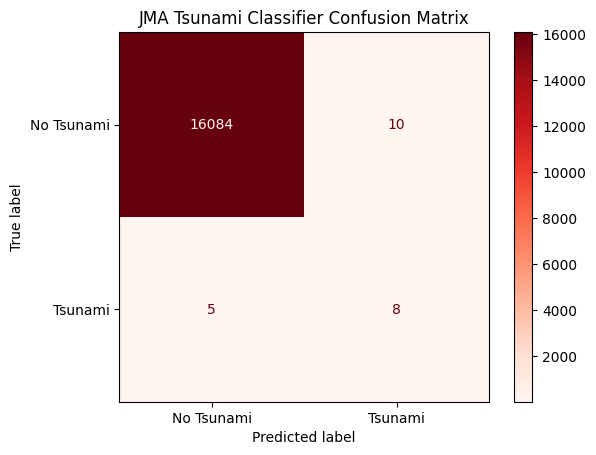

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tsunami", "Tsunami"]
)

disp.plot(cmap="Reds")
plt.title("JMA Tsunami Classifier Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

#Report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["No Tsunami", "Tsunami"],
    output_dict=True
)

#Table dataframe
df_report = pd.DataFrame(report_dict).transpose()

df_report = df_report.round(3)

df_report

,precision,recall,f1-score,support
No Tsunami,1.000,0.999,1.000,16094.000
Tsunami,0.444,0.615,0.516,13.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.722,0.807,0.758,16107.000
weighted avg,0.999,0.999,0.999,16107.000


Solo 13 tsunami su 16.107 eventi  
Il modello sta trovando tsunami reali (recall = 0.62)

**Interpretazione:**

* No Tsunami: direi che va bene

* Tsunami:   
Recall 0.62 → intercetti ~62% degli tsunami reali  
Precision 0.44 → alcuni falsi positivi (accettabile in early-warning)  
F1 0.52 → buono, considerando lo sbilanciamento

**Da sistemare:**
* I parametri dei dati finti del primo allenamento
* Grafico dell'accuracy e della loss con i dati veri